In [20]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests
from itertools import combinations
from collections import Counter

# Set seaborn theme globally
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.2)

# ===========================================================================
# 1. Helper Functions (Ported from visualizations.ipynb)
# ===========================================================================

def plot_histograms(projects, actions):
    contributors_per_project(projects)
    success_rate_over_time(projects)
    quality_metrics_over_time(projects)
    collab_metrics_over_time(projects)
    projects_per_contributor(projects)
    completion_per_project(projects)
    quality_per_project(projects)

def contributors_per_project(projects):
    num_contributors = [len(p["contributors"]) for p in projects]
    plt.figure(figsize=(8, 5))
    sns.histplot(num_contributors, bins=range(1, max(num_contributors) + 2), kde=False, discrete=True)
    plt.xlabel("Number of Contributors")
    plt.ylabel("Number of Projects")
    plt.title("Distribution of Contributors per Project")
    plt.tight_layout()
    plt.show()

def success_rate_over_time(projects):
    events = [(p["start_time"], p["finished"], p["final_reward"]) for p in projects]
    events.sort(key=lambda x: x[0])
    time_steps, success_rates = [], []
    finished, successful = 0, 0
    for t, is_finished, score in events:
        if is_finished:
            finished += 1
            if score > 0: successful += 1
        success_rates.append(successful / finished if finished > 0 else 0)
        time_steps.append(t)
    plt.figure(figsize=(8, 5))
    sns.lineplot(x=time_steps, y=success_rates)
    plt.xlabel("Time Step")
    plt.ylabel("Success Rate")
    plt.title("Project Success Rate Over Time")
    plt.ylim(0, 1.05)
    plt.tight_layout()
    plt.show()

def quality_metrics_over_time(projects):
    projects_per_time = {p["start_time"]:[] for p in projects}
    for p in projects: projects_per_time[p["start_time"]].append(p)
    projects_sorted = sorted(projects_per_time.items(), key=lambda p: p[0])
    times = [t for t, _ in projects_sorted]
    quality = [np.mean([p["quality_score"] for p in pjs]) for _, pjs in projects_sorted]
    novelty = [np.mean([p["novelty_score"] for p in pjs]) for _, pjs in projects_sorted]
    value = [np.mean([p["societal_value_score"] for p in pjs]) for _, pjs in projects_sorted]
    plt.figure(figsize=(10, 6))
    sns.lineplot(x=times, y=quality, label="Quality Score")
    sns.lineplot(x=times, y=novelty, label="Novelty")
    sns.lineplot(x=times, y=value, label="Societal Value")
    plt.xlabel("Time Step")
    plt.ylabel("Value")
    plt.title("Project Metrics Over Time")
    plt.legend()
    plt.show()

def collab_metrics_over_time(projects):
    projects_per_time = {p["start_time"]: [] for p in projects}
    for p in projects: projects_per_time[p["start_time"]].append(p)
    projects_sorted = sorted(projects_per_time.items(), key=lambda p: p[0])
    times = [t for t, _ in projects_sorted]
    effort = [np.mean([p["current_effort"] for p in pjs]) for _, pjs in projects_sorted]
    n_contributors = [np.mean([len(p["contributors"]) for p in pjs]) for _, pjs in projects_sorted]
    citations = [np.sum([len(p.get("citations", [])) for p in pjs]) for _, pjs in projects_sorted]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)
    sns.lineplot(x=times, y=effort, ax=axes[0])
    axes[0].set_title("Current Effort")
    sns.lineplot(x=times, y=n_contributors, ax=axes[1])
    axes[1].set_title("# Contributors per Paper")
    sns.lineplot(x=times, y=citations, ax=axes[2])
    axes[2].set_title("Citations")
    plt.tight_layout()
    plt.show()

def projects_per_contributor(projects):
    all_contributors = []
    for p in projects: all_contributors.extend(p["contributors"])
    author_counts = Counter(all_contributors)
    papers_per_author = list(author_counts.values())
    plt.figure(figsize=(8, 5))
    sns.histplot(papers_per_author, bins=range(1, max(papers_per_author) + 2), kde=False, discrete=True)
    plt.xlabel("Number of Papers per Author")
    plt.ylabel("Number of Authors")
    plt.title("Authors by Number of Papers")
    plt.tight_layout()
    plt.show()

def completion_per_project(projects):
    completion = [max(0, p["current_effort"] / p["required_effort"]) * 100 for p in projects]
    plt.figure(figsize=(8, 5))
    sns.histplot(completion, bins=range(0, 110, 10), kde=False)
    plt.xlabel("Completion (%)")
    plt.ylabel("Number of Projects")
    plt.title("Distribution of Project Completion")
    plt.tight_layout()
    plt.show()

def quality_per_project(projects):
    quality_scores = [p["quality_score"] for p in projects]
    plt.figure(figsize=(8, 5))
    sns.histplot(quality_scores, bins=[i/10 for i in range(0, 11)], kde=False)
    plt.xlabel("Quality Score")
    plt.ylabel("Number of Projects")
    plt.title("Distribution of Project Quality Scores")
    plt.tight_layout()
    plt.show()

# ===========================================================================
# 2. RL Specific Visualization Functions
# ===========================================================================

def plot_mean_reward_trajectories_with_rl(dfs_heuristic, df_rl, strategy_name="by_effort", normalize=True):
    df_h, df_r = dfs_heuristic.copy(), df_rl.copy()
    all_archetypes = sorted(list(df_h["archetype"].unique()))
    palette = sns.color_palette("tab10", len(all_archetypes) + 1)
    color_map = {a: palette[i] for i, a in enumerate(all_archetypes)}
    color_map["rl_agent"] = "red"
    plt.figure(figsize=(12, 7))
    if normalize:
        max_val = max(df_h["mean_reward"].max(), df_r["mean_reward"].max())
        if max_val > 0:
            df_h["mean_reward"] /= max_val
            df_r["mean_reward"] /= max_val
    for archetype, group_arch in df_h.groupby("archetype"):
        summary_h = group_arch.groupby("step")["mean_reward"].mean().reset_index()
        plt.plot(summary_h["step"], summary_h["mean_reward"], label=archetype, color=color_map[archetype], lw=2, alpha=0.7)
    summary_rl = df_r.groupby("step").agg(mean_across_seeds=("mean_reward", "mean"), std_across_seeds=("mean_reward", "std")).reset_index()
    plt.plot(summary_rl["step"], summary_rl["mean_across_seeds"], label="rl_agent (PPO)", color=color_map["rl_agent"], lw=4, zorder=5)
    plt.fill_between(summary_rl["step"], summary_rl["mean_across_seeds"] - summary_rl["std_across_seeds"], summary_rl["mean_across_seeds"] + summary_rl["std_across_seeds"], color=color_map["rl_agent"], alpha=0.2, zorder=4)
    plt.title(f"Performance Comparison: RL_Agent vs. Heuristics ({strategy_name})")
    plt.ylabel("Normalized Accumulated Reward" if normalize else "Accumulated Reward")
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

def plot_rl_metrics_distribution(df_rl, strategy_name="by_effort"):
    final_states = df_rl[df_rl["archetype"] == "rl_agent"].groupby("seed").last().reset_index()
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    sns.boxplot(y=final_states["h_index"], ax=axes[0], color="skyblue")
    sns.stripplot(y=final_states["h_index"], ax=axes[0], color="black", alpha=0.5)
    axes[0].set_title(f"RL Agent H-Index Distribution ({strategy_name})")
    sns.boxplot(y=final_states["age"], ax=axes[1], color="lightgreen")
    sns.stripplot(y=final_states["age"], ax=axes[1], color="black", alpha=0.5)
    axes[1].set_title(f"RL Agent Lifespan Distribution ({strategy_name})")
    plt.tight_layout()
    plt.show()


In [21]:
# ## 1. Aggregate Empirical Results (RL vs Heuristics)
# This section uses the data generated by `process_results.py` and `process_rl_results.py`.


✅ Empirical data loaded successfully.


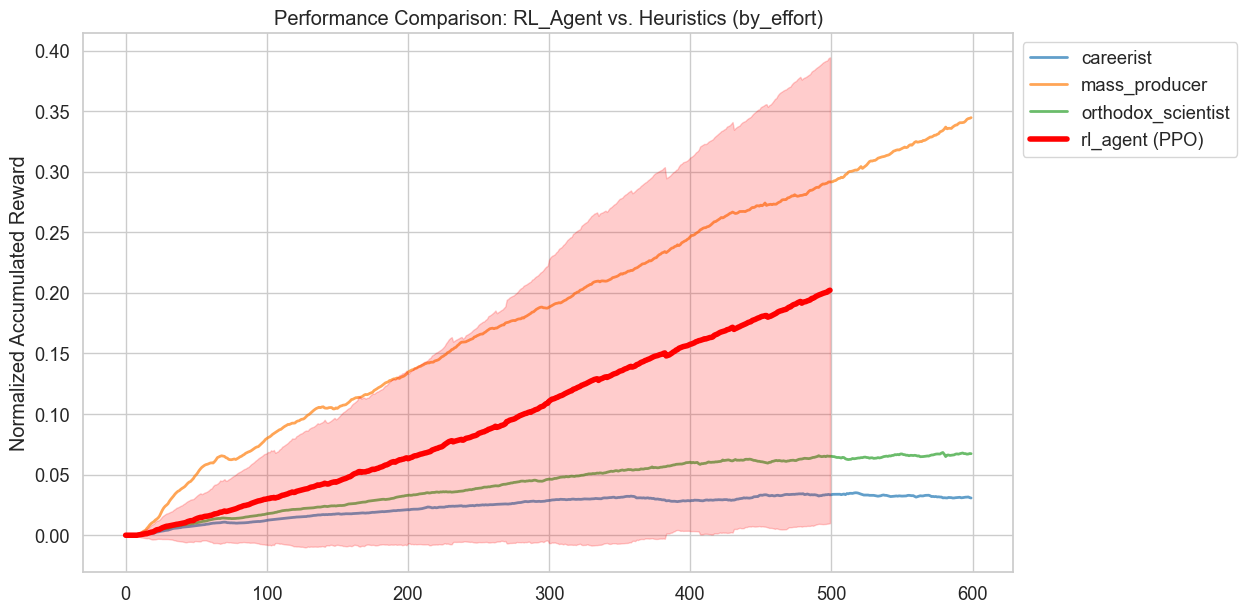

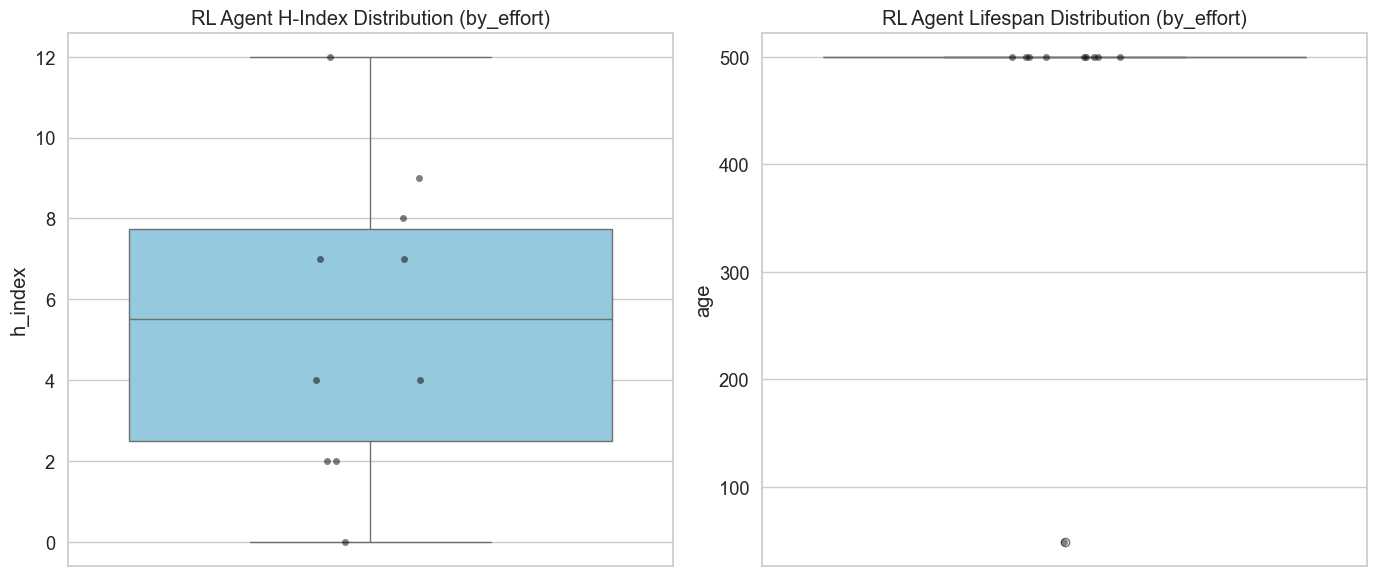

In [22]:
try:
    df_h_effort = pd.read_parquet("results/reward_summary_by_archetype_by_effort.parquet")
    df_rl_summary = pd.read_parquet("results/rl_summary_by_archetype_by_effort.parquet")
    df_rl_trajectories = pd.read_parquet("results/rl_trajectories_by_effort.parquet")
    print("✅ Empirical data loaded successfully.")
    
    plot_mean_reward_trajectories_with_rl(df_h_effort, df_rl_summary, strategy_name="by_effort")
    plot_rl_metrics_distribution(df_rl_trajectories, strategy_name="by_effort")
except FileNotFoundError as e:
    print(f"❌ Error loading data: {e}. Ensure you have run the aggregation scripts.")


In [23]:
# ## 2. Detailed Simulation Analysis (Single Seed)
# This section performs a deep dive into one specific RL simulation run (e.g. Seed 101).


In [24]:
# Load single seed logs for project-level analysis
SEED = 101
STRAT = "by_effort"
try:
    with open(f"log/rl_ppo_{STRAT}_s{SEED}_projects.json", "r") as f:
        projects = json.load(f)
    with open(f"log/rl_ppo_{STRAT}_s{SEED}_actions.jsonl", "r") as f:
        actions = [json.loads(line) for line in f]
    print(f"✅ Loaded detailed logs for Seed {SEED}")
    
    # Run the standard visualization suite
    plot_histograms(projects, actions)
except FileNotFoundError as e:
    print(f"❌ Could not load detailed logs for Seed {SEED}: {e}")


❌ Could not load detailed logs for Seed 101: [Errno 2] No such file or directory: 'log/rl_ppo_by_effort_s101_projects.json'


In [25]:
# ### Archetype Proportions Over Time
# Tracks how the population composition (heuristic types + RL agent) changes during the run.

In [26]:
def visualize_policy_population(simulation_steps):
    records = []
    for step_idx, step in enumerate(simulation_steps):
        for agent_id, agent in step.items():
            if agent is not None:
                records.append({"step": step_idx, "archetype": agent.get("archetype", "rl_agent")})
    df = pd.DataFrame(records)
    counts = df.groupby(["step", "archetype"]).size().reset_index(name="count")
    pivot = counts.pivot(index="step", columns="archetype", values="count").fillna(0)
    
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)
    pivot.plot.line(ax=axes[0])
    axes[0].set_title("Population Composition Over Time")
    axes[0].legend(title="Archetype", bbox_to_anchor=(1.05, 1), loc="upper left")
    pivot.sum(axis=1).plot(ax=axes[1], color="black")
    axes[1].set_ylabel("Total Agents")
    plt.tight_layout()
    plt.show()

if 'actions' in locals():
    visualize_policy_population(actions)
